# Stop Signal Task (SST) Analysis

This notebook analyzes SST data from both datapruebas and neuropruebas sources.

## Usage
There are two ways to use this notebook:

1. **Load existing analysis** (fast): Use `get_latest_sst_analysis()` to load pre-computed results
2. **Run fresh analysis** (slow): Execute the full pipeline with `load_sst_analysis()`

To run the analysis from command line:
```bash
python -m src.loader.sst_analysis_loader
```

## Metrics computed:
- **SSRT** (Stop Signal Reaction Time): Main measure of inhibitory control
- **presp**: Probability of responding on stop trials
- **SSD**: Stop Signal Delay
- **goRT_all**: Mean RT on go trials
- **go_omission**: Proportion of omitted go trials
- **go_error**: Proportion of errors on go trials


In [26]:
import os
import sys

# Add project root to path
project_root = os.path.dirname(os.getcwd())
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.analysis import StopSignalTask
from src.loader import load_sst_experiment, load_sst_analysis, get_latest_sst_analysis
from src import config

# Plot settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
%matplotlib inline


## 1. Load Data

**Option A**: Load latest pre-computed analysis (fast)


In [16]:
# Load latest pre-computed analysis
result = get_latest_sst_analysis()

if result is not None:
    df_sst_all, run_config = result
    print(f"Loaded analysis from: {run_config.get('timestamp', 'unknown')}")
    print(f"Total subjects: {len(df_sst_all)}")
    
    # Split by origin for compatibility with rest of notebook
    df_sst_datapruebas = df_sst_all[df_sst_all["origin"] == "datapruebas"].copy()
    df_sst_neuropruebas = df_sst_all[df_sst_all["origin"] == "neuropruebas"].copy()
    print(f"  - Datapruebas: {len(df_sst_datapruebas)}")
    print(f"  - Neuropruebas: {len(df_sst_neuropruebas)}")
else:
    print("No pre-computed analysis found. Run Option B below or execute:")
    print("  python -m src.loader.sst_analysis_loader")


Loaded analysis from: 2026-01-12_12-05-07
Total subjects: 246
  - Datapruebas: 57
  - Neuropruebas: 189


**Option B**: Run fresh analysis (slow, use if no pre-computed data exists)


In [17]:
# SKIP THIS CELL if you already loaded data in Option A
# Uncomment and run only if you need fresh analysis

# df_sst_all, save_path = load_sst_analysis(save_results=True)
# df_sst_datapruebas = df_sst_all[df_sst_all["origin"] == "datapruebas"].copy()
# df_sst_neuropruebas = df_sst_all[df_sst_all["origin"] == "neuropruebas"].copy()
# print(f"Analysis complete. Saved to: {save_path}")


In [18]:
## 2. Data Overview


In [19]:
# Quick view of the data
print(f"Total subjects: {len(df_sst_all)}")
print(f"Columns: {list(df_sst_all.columns)}")
df_sst_all.head(10)


Total subjects: 246
Columns: ['subject_id', 'Nstop', 'presp', 'ssd', 'usRT', 'goRT_all', 'goRT_sd', 'nth', 'goRT_correct', 'go_omission', 'go_error', 'go_premature', 'ssrt', 'origin']


,subject_id,Nstop,presp,ssd,usRT,goRT_all,goRT_sd,nth,goRT_correct,go_omission,go_error,go_premature,ssrt,origin
0,b658934b-1bbc-4897-a989-1827a61cfb03,64,0.468750,245,435,495,97,479,496,0.000000,0.005236,0,234,datapruebas
1,5c1c9209-2512-44b9-8686-4778e212299e,64,0.406250,723,828,892,202,877,892,0.135417,0.000000,0,154,datapruebas
2,d09f5193-6096-4dee-bc8f-92f04743528c,63,0.460317,423,580,655,154,652,660,0.000000,0.031250,0,229,datapruebas
3,7d540a4e-9e01-472d-93aa-37f42cbfc693,64,0.515625,200,414,462,77,450,462,0.000000,0.000000,0,250,datapruebas
4,3f45b93b-b0e2-427d-a081-40a19722db2f,64,0.421875,428,549,700,182,685,700,0.010417,0.000000,0,257,datapruebas
5,39675e5b-4e50-4bb2-9764-e434c64b3b8a,64,0.468750,302,371,438,144,391,442,0.000000,0.015625,0,89,datapruebas
6,19e5c3c3-6564-4280-8154-225ac8b69d83,64,0.453125,602,607,777,277,824,778,0.073298,0.011299,0,222,datapruebas
7,d82cfda0-f10e-4619-bff0-d78b387387f5,64,0.468750,494,610,680,151,661,680,0.000000,0.000000,0,167,datapruebas
8,5d7d8bd4-bca9-42cc-95a7-1e4f284962f0,63,0.507937,251,378,514,213,432,516,0.005208,0.010471,0,181,datapruebas
9,a740ac85-3681-4e14-a510-43c23a09286b,64,0.546875,113,362,405,73,395,407,0.000000,0.031250,0,282,datapruebas


## 3. Descriptive Statistics


In [20]:
# Summary statistics by origin
metrics_cols = ["ssrt", "presp", "ssd", "goRT_all", "goRT_sd", "go_omission", "go_error"]
df_sst_all.groupby("origin")[metrics_cols].describe().T


origin             datapruebas  neuropruebas
ssrt        count    57.000000    189.000000
            mean    220.403509    229.962963
            std      46.284392     50.058410
            min      89.000000     69.000000
            25%     194.000000    203.000000
            50%     214.000000    236.000000
            75%     259.000000    263.000000
            max     321.000000    354.000000
presp       count    57.000000    189.000000
            mean      0.476691      0.485283
            std       0.035854      0.054051
            min       0.390625      0.285714
            25%       0.453125      0.453125
            50%       0.484375      0.484375
            75%       0.500000      0.500000
            max       0.546875      0.777778
ssd         count    57.000000    189.000000
            mean    333.578947    308.555556
            std     175.728377    198.295458
            min      95.000000     64.000000
            25%     200.000000    152.000000
            50%     302.000000    245.000000
            75%     445.000000    420.000000
            max     744.000000   1015.000000
goRT_all    count    57.000000    189.000000
            mean    572.824561    553.724868
            std     162.071867    177.778575
            min     305.000000    307.000000
            25%     457.000000    410.000000
            50%     549.000000    494.000000
            75%     680.000000    664.000000
            max     907.000000   1081.000000
goRT_sd     count    57.000000    189.000000
            mean    144.157895    128.904762
            std      64.836550     63.021032
            min      44.000000     42.000000
            25%      86.000000     73.000000
            50%     141.000000    118.000000
            75%     197.000000    177.000000
            max     277.000000    288.000000
go_omission count    57.000000    189.000000
            mean      0.012988      0.020882
            std       0.024350      0.060641
            min       0.000000      0.000000
            25%       0.000000      0.000000
            50%       0.000000      0.000000
            75%       0.015625      0.015625
            max       0.135417      0.609626
go_error    count    57.000000    189.000000
            mean      0.009890      0.015183
            std       0.011565      0.027043
            min       0.000000      0.000000
            25%       0.000000      0.000000
            50%       0.005348      0.005236
            75%       0.015625      0.016575
            max       0.046875      0.213542

In [21]:
# SSRT descriptive stats
print("SSRT Statistics by Origin:")
print("=" * 40)
print("\nDatapruebas:")
print(df_sst_datapruebas["ssrt"].describe())
print("\nNeuropruebas:")
print(df_sst_neuropruebas["ssrt"].describe())


SSRT Statistics by Origin:

Datapruebas:
count     57.000000
mean     220.403509
std       46.284392
min       89.000000
25%      194.000000
50%      214.000000
75%      259.000000
max      321.000000
Name: ssrt, dtype: float64

Neuropruebas:
count    189.000000
mean     229.962963
std       50.058410
min       69.000000
25%      203.000000
50%      236.000000
75%      263.000000
max      354.000000
Name: ssrt, dtype: float64


## 4. SSRT Distribution


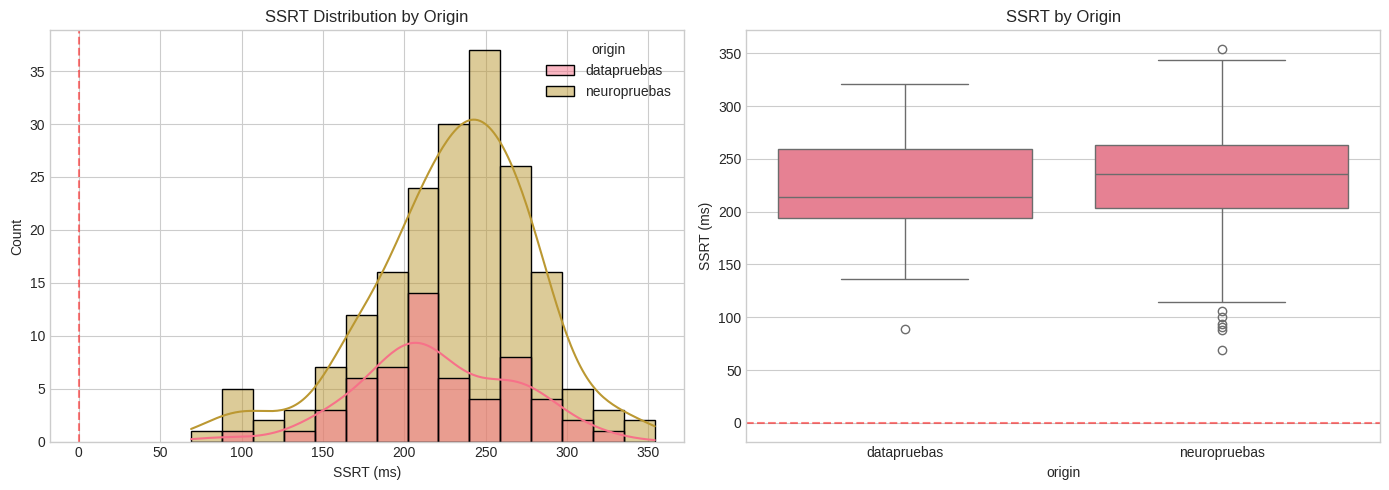

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograms
ax1 = axes[0]
sns.histplot(data=df_sst_all, x="ssrt", hue="origin", kde=True, ax=ax1)
ax1.set_title("SSRT Distribution by Origin")
ax1.set_xlabel("SSRT (ms)")
ax1.axvline(x=0, color='red', linestyle='--', alpha=0.5, label='Zero line')

# Box plot
ax2 = axes[1]
sns.boxplot(data=df_sst_all, x="origin", y="ssrt", ax=ax2)
ax2.set_title("SSRT by Origin")
ax2.set_ylabel("SSRT (ms)")
ax2.axhline(y=0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


## 5. Quality Control Checks

Identifying potentially invalid data based on common SST quality criteria.


In [23]:
# Check for negative SSRT (invalid)
negative_ssrt = df_sst_all[df_sst_all["ssrt"] < 0]
print(f"Subjects with negative SSRT: {len(negative_ssrt)}")
if len(negative_ssrt) > 0:
    display(negative_ssrt[["Subject", "origin", "ssrt", "presp", "ssd"]])


Subjects with negative SSRT: 0


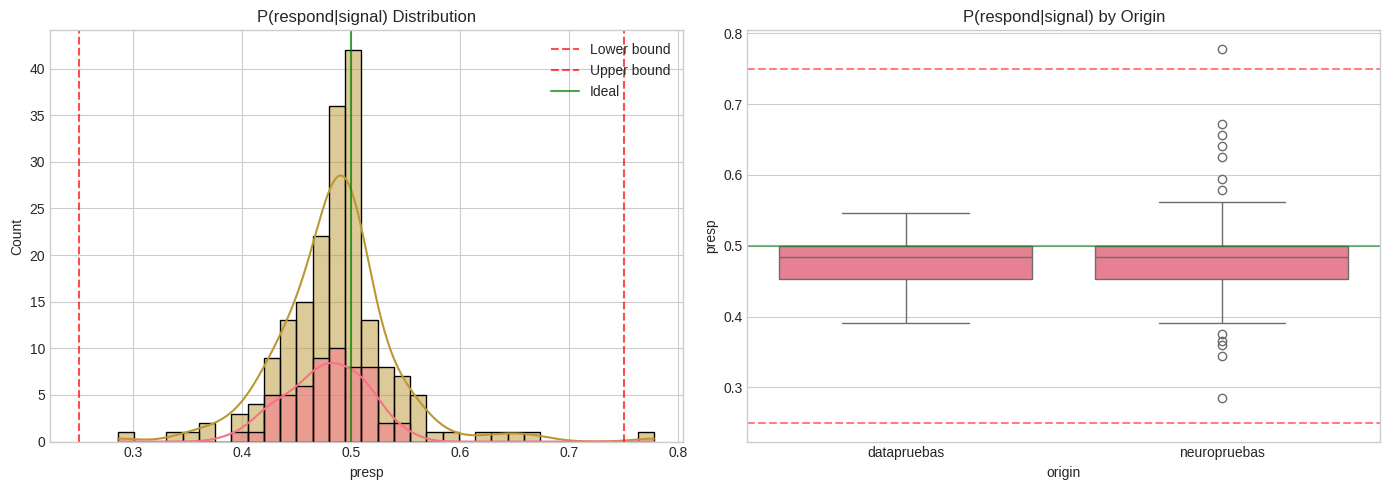

In [24]:
# Check presp distribution (should be ~0.5 for valid tracking)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
sns.histplot(data=df_sst_all, x="presp", hue="origin", kde=True, ax=ax1)
ax1.set_title("P(respond|signal) Distribution")
ax1.axvline(x=0.25, color='red', linestyle='--', alpha=0.7, label='Lower bound')
ax1.axvline(x=0.75, color='red', linestyle='--', alpha=0.7, label='Upper bound')
ax1.axvline(x=0.5, color='green', linestyle='-', alpha=0.7, label='Ideal')
ax1.legend()

ax2 = axes[1]
sns.boxplot(data=df_sst_all, x="origin", y="presp", ax=ax2)
ax2.set_title("P(respond|signal) by Origin")
ax2.axhline(y=0.5, color='green', linestyle='-', alpha=0.5)
ax2.axhline(y=0.25, color='red', linestyle='--', alpha=0.5)
ax2.axhline(y=0.75, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


In [25]:
# Subjects with extreme presp (< 0.25 or > 0.75)
extreme_presp = df_sst_all[(df_sst_all["presp"] < 0.25) | (df_sst_all["presp"] > 0.75)]
print(f"Subjects with extreme presp (<0.25 or >0.75): {len(extreme_presp)}")
if len(extreme_presp) > 0:
    display(extreme_presp[["Subject", "origin", "presp", "ssrt", "go_omission"]])


Subjects with extreme presp (<0.25 or >0.75): 1


KeyError: "['Subject'] not in index"

In [12]:
# Check go_omission (high omission rate suggests inattention)
high_omission = df_sst_all[df_sst_all["go_omission"] > 0.2]
print(f"Subjects with high go_omission (>0.2): {len(high_omission)}")
if len(high_omission) > 0:
    display(high_omission[["Subject", "origin", "go_omission", "ssrt", "presp"]].sort_values("go_omission", ascending=False))


Subjects with high go_omission (>0.2): 5


,Subject,origin,go_omission,ssrt,presp
30,77fa21ff-94ed-40e3-92e8-f868aec74b50,datapruebas,0.640625,-112,0.296875
147,constanzafperez@gmail.com-stop-signal-task_72,neuropruebas,0.593750,103,0.296875
228,6507040d-5311-41e7-b163-2e3a432c28e8,neuropruebas,0.364583,198,0.343750
99,alejandrohacker42@gmail.com-stop-signal-task_68,neuropruebas,0.229167,194,0.437500
86,josefinamercedescaso@gmail.com-stop-signal-tas...,neuropruebas,0.208333,256,0.500000


## 6. Go RT vs Stop Signal RT


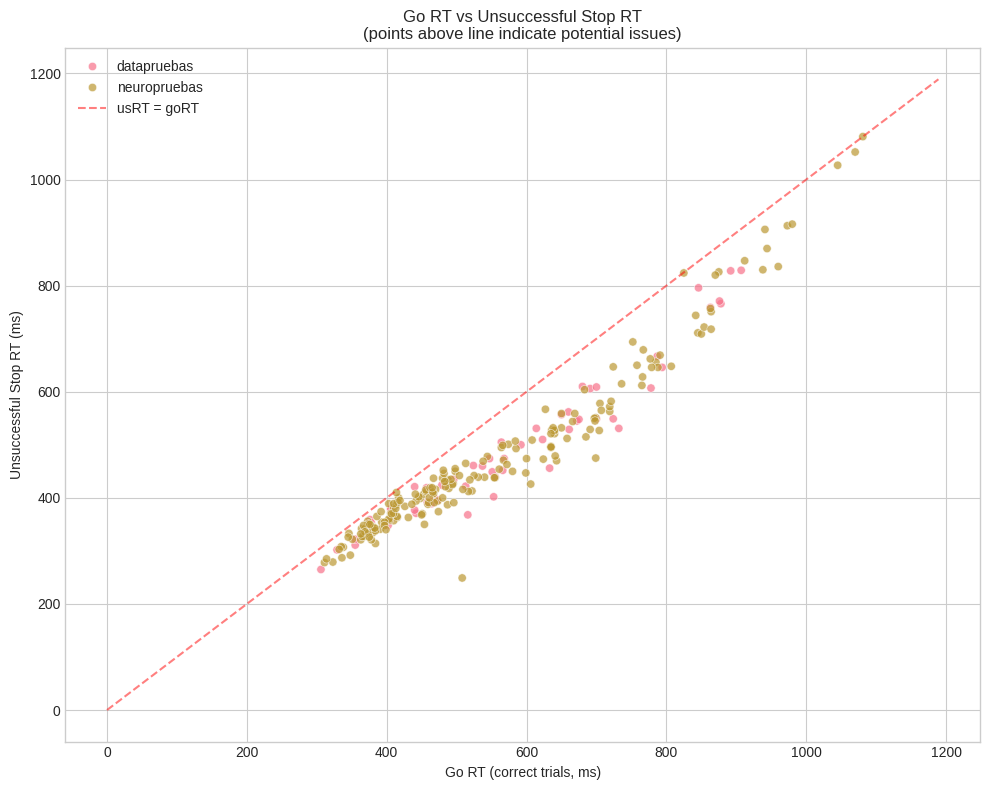


Subjects where usRT > goRT_correct: 0


In [13]:
fig, ax = plt.subplots(figsize=(10, 8))

sns.scatterplot(
    data=df_sst_all,
    x="goRT_correct",
    y="usRT",
    hue="origin",
    alpha=0.7,
    ax=ax
)

# Add diagonal line (usRT should be < goRT for valid data)
lims = [0, max(df_sst_all["goRT_correct"].max(), df_sst_all["usRT"].max()) * 1.1]
ax.plot(lims, lims, 'r--', alpha=0.5, label='usRT = goRT')

ax.set_xlabel("Go RT (correct trials, ms)")
ax.set_ylabel("Unsuccessful Stop RT (ms)")
ax.set_title("Go RT vs Unsuccessful Stop RT\n(points above line indicate potential issues)")
ax.legend()

plt.tight_layout()
plt.show()

# Check for violations
violations = df_sst_all[df_sst_all["usRT"] > df_sst_all["goRT_correct"]]
print(f"\nSubjects where usRT > goRT_correct: {len(violations)}")


## 7. Re-run and Save Results (Optional)

If you made changes to the analysis or want to create a new timestamped run:


In [ ]:
# Uncomment to run fresh analysis and save results
# This will create a new timestamped folder with results

# df_sst_all, save_path = load_sst_analysis(save_results=True)
# print(f"Results saved to: {save_path}")

# Or run from command line:
# !python -m src.loader.sst_analysis_loader


Saved combined results to: /home/gianluca/Research/datapruebas_analysis/data/processed/sst/sst_analyzed_all.csv
Saved individual results to: /home/gianluca/Research/datapruebas_analysis/data/processed/sst


## 8. Summary

Key findings from SST analysis:


In [15]:
print("SST Analysis Summary")
print("=" * 50)
print(f"\nTotal subjects analyzed: {len(df_sst_all)}")
print(f"  - Datapruebas: {len(df_sst_datapruebas)}")
print(f"  - Neuropruebas: {len(df_sst_neuropruebas)}")
print(f"\nMean SSRT: {df_sst_all['ssrt'].mean():.1f} ms (SD={df_sst_all['ssrt'].std():.1f})")
print(f"Mean presp: {df_sst_all['presp'].mean():.2f}")
print(f"\nPotential quality issues:")
print(f"  - Negative SSRT: {len(negative_ssrt)} subjects")
print(f"  - Extreme presp: {len(extreme_presp)} subjects")
print(f"  - High go_omission: {len(high_omission)} subjects")


SST Analysis Summary

Total subjects analyzed: 247
  - Datapruebas: 58
  - Neuropruebas: 189

Mean SSRT: 226.5 ms (SD=54.0)
Mean presp: 0.48

Potential quality issues:
  - Negative SSRT: 1 subjects
  - Extreme presp: 1 subjects
  - High go_omission: 5 subjects


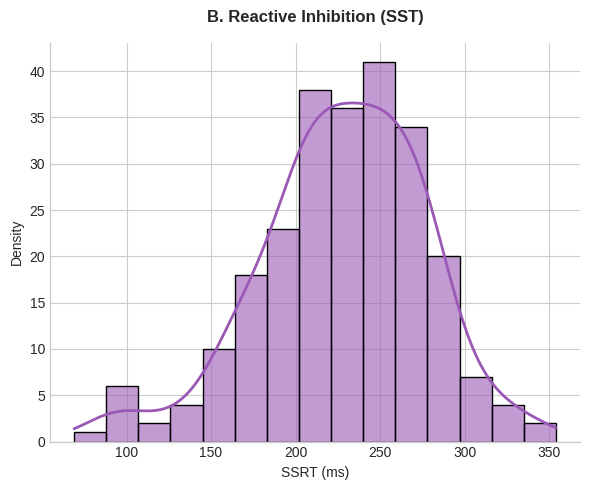

In [27]:
plt.figure(figsize=(6, 5))
sns.histplot(
    data=df_sst_all, 
    x='ssrt', 
    kde=True, 
    color='#9b59b6', 
    line_kws={'linewidth': 2}, 
    alpha=0.6
)
plt.title('B. Reactive Inhibition (SST)', fontweight='bold', pad=15)
plt.ylabel('Density')
plt.xlabel('SSRT (ms)')
sns.despine()
plt.tight_layout()
# plt.savefig('Figure_2B_SST.png', dpi=300)
plt.show()